Saving loan_applicants_dataset.csv to loan_applicants_dataset (2).csv
Accuracy: 0.969
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       368
           1       0.97      0.98      0.98       632

    accuracy                           0.97      1000
   macro avg       0.97      0.96      0.97      1000
weighted avg       0.97      0.97      0.97      1000



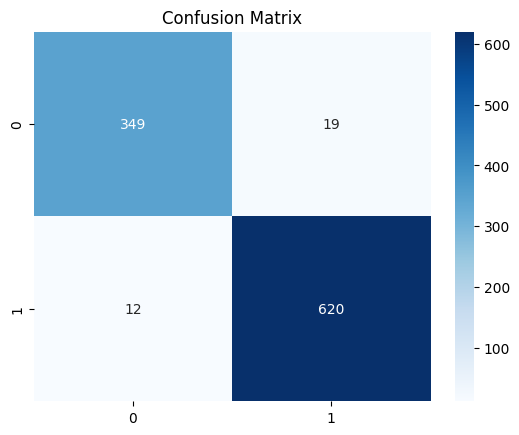

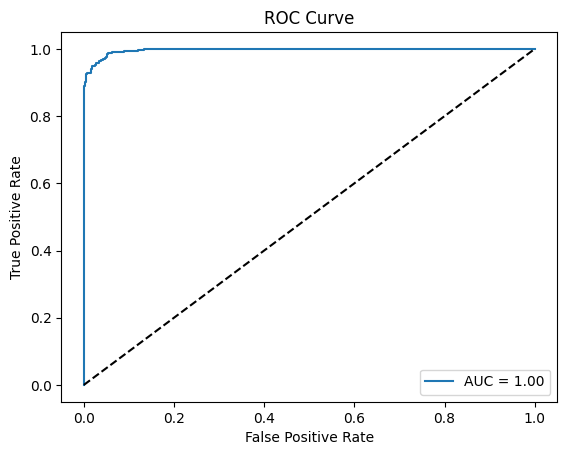

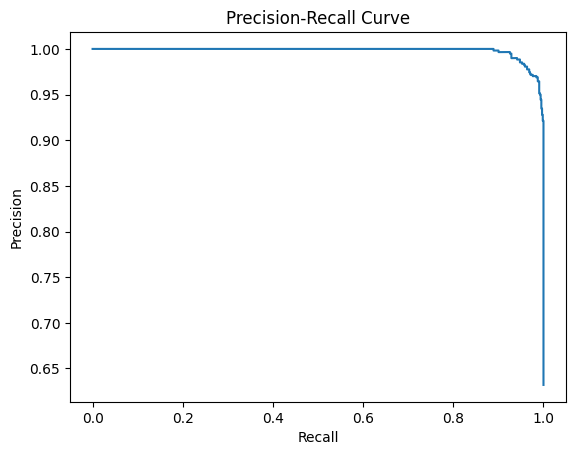

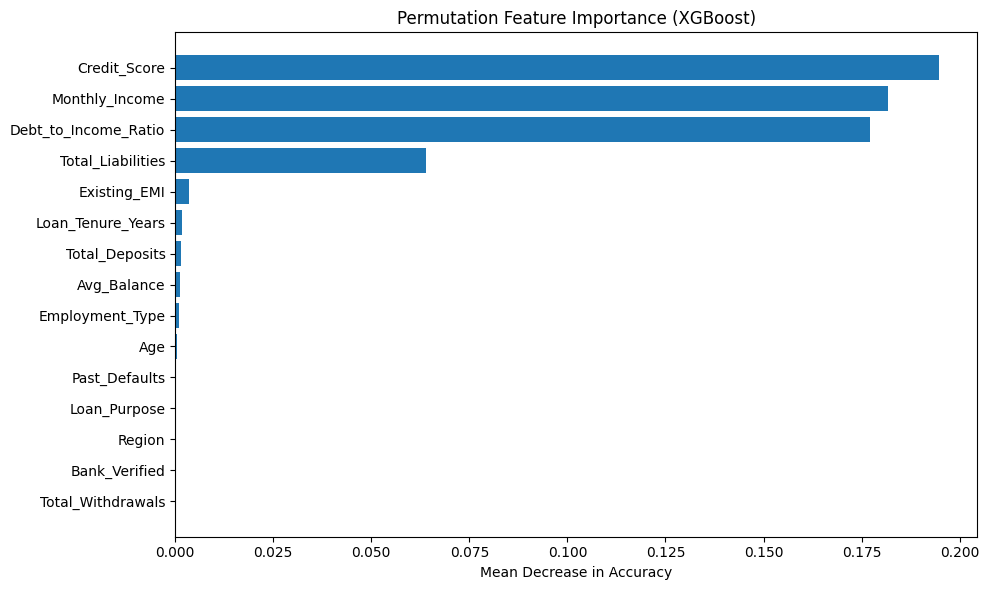

   Monthly_Income  Credit_Score  Predicted_Probability  \
0           60000           750               0.999979   
1           35000           610               0.000112   

   Loan_Approved_Prediction  
0                         1  
1                         0  


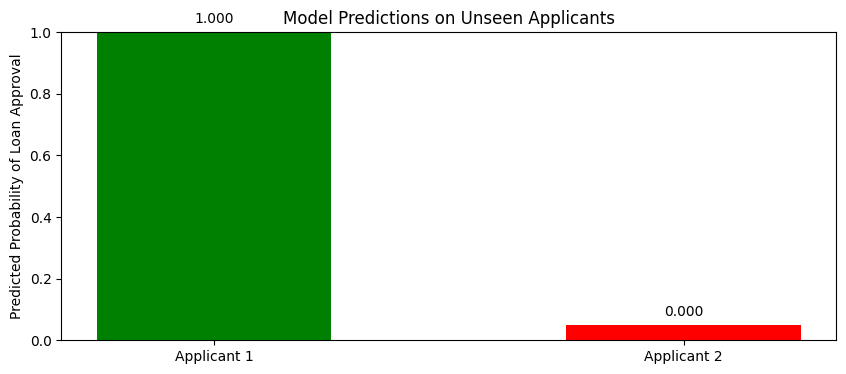

In [ ]:
# =========================
# 1️⃣ Load Data
# =========================
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Upload your dataset
df = pd.read_csv('loan_applicants_dataset.csv')

# Drop non-numeric columns not needed for prediction
df = df.drop(columns=['Customer_ID', 'Name', 'Eligibility_Score'], errors='ignore')

# =========================
# 2️⃣ Encode Categorical Columns
# =========================
from sklearn.preprocessing import LabelEncoder
import joblib
import os # Import the os module

cat_cols = ["Gender","Marital_Status","Employment_Type","Bank_Statement_Verified",
            "Voice_Verified","Document_Verified","Region","Loan_Purpose",
            "Salary_Credit_Frequency","Bank_Verified"]

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(df[col])
    df[col] = le.transform(df[col])
    encoders[col] = le

# Save encoders for deployment
save_dir = '/content/drive/MyDrive/Infosys Project/' # Define the directory
os.makedirs(save_dir, exist_ok=True) # Create the directory if it doesn't exist
joblib.dump(encoders, save_dir + 'label_encoders.pkl') # Save the file in the directory

# =========================
# 3️⃣ Split Data & Train Model
# =========================
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

# Save model
joblib.dump(model, save_dir + 'loan_xgboost_model.pkl') # Save the model in the directory

# =========================
# 4️⃣ Evaluate Model
# =========================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# Feature Importance (Permutation)
from sklearn.inspection import permutation_importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()
plt.figure(figsize=(10, 6))
plt.barh(X_test.columns[sorted_idx][-15:], result.importances_mean[sorted_idx][-15:])
plt.xlabel("Mean Decrease in Accuracy")
plt.title("Permutation Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()

# =========================
# 5️⃣ Predict on New Applicants
# =========================
new_applicants = pd.DataFrame([
    {
        "Age": 28, "Gender": "M", "Marital_Status": "Single", "Employment_Type": "Job",
        "Monthly_Income": 60000, "Loan_Amount_Requested": 400000, "Credit_Score": 750,
        "Existing_EMI": 10000, "Loan_Tenure_Years": 5, "Dependents": 1,
        "Bank_Statement_Verified": "Yes", "Voice_Verified": "Yes", "Document_Verified": "Yes",
        "Total_Liabilities": 50000, "Past_Defaults": 0, "Region": "Delhi", "Loan_Purpose": "Home",
        "Total_Withdrawals": 200000, "Total_Deposits": 250000, "Avg_Balance": 40000,
        "Bounced_Transactions": 0, "Account_Age_Months": 36,
        "Salary_Credit_Frequency": "Monthly", "Bank_Verified": "Yes",
        "Debt_to_Income_Ratio": 0.17
    },
    {
        "Age": 45, "Gender": "F", "Marital_Status": "Married", "Employment_Type": "Self-employed",
        "Monthly_Income": 35000, "Loan_Amount_Requested": 700000, "Credit_Score": 610,
        "Existing_EMI": 18000, "Loan_Tenure_Years": 7, "Dependents": 3,
        "Bank_Statement_Verified": "No", "Voice_Verified": "No", "Document_Verified": "No",
        "Total_Liabilities": 400000, "Past_Defaults": 2, "Region": "Mumbai", "Loan_Purpose": "Business",
        "Total_Withdrawals": 350000, "Total_Deposits": 300000, "Avg_Balance": 15000,
        "Bounced_Transactions": 3, "Account_Age_Months": 24,
        "Salary_Credit_Frequency": "Irregular", "Bank_Verified": "No",
        "Debt_to_Income_Ratio": 0.51
    }
])

# Encode categorical columns using saved encoders
encoders = joblib.load(save_dir + 'label_encoders.pkl') # Load the encoders from the directory
for col in cat_cols:
    le = encoders[col]
    import numpy as np # Import numpy
    new_applicants[col] = new_applicants[col].map(lambda s: 'Unknown' if s not in le.classes_ else s)
    le_classes = list(le.classes_)
    if 'Unknown' not in le_classes:
        le_classes.append('Unknown')
        le.classes_ = np.array(le_classes)
    new_applicants[col] = le.transform(new_applicants[col])

# Predict
pred_probs = model.predict_proba(new_applicants)[:, 1]
pred_labels = model.predict(new_applicants)

new_applicants["Predicted_Probability"] = pred_probs
new_applicants["Loan_Approved_Prediction"] = pred_labels

print(new_applicants[["Monthly_Income", "Credit_Score", "Predicted_Probability", "Loan_Approved_Prediction"]])

# Optional: Plot predictions
import matplotlib.pyplot as plt

df_plot = new_applicants.reset_index(drop=True)

# Add small visible offset for very small probabilities
visible_height = df_plot["Predicted_Probability"].apply(lambda x: x if x > 0.05 else 0.05)

plt.figure(figsize=(10, 4))
plt.bar(df_plot.index,
        visible_height,
        color=['green' if x==1 else 'red' for x in df_plot["Loan_Approved_Prediction"]],
        width=0.5)

plt.xticks(df_plot.index, ["Applicant 1", "Applicant 2"])
plt.ylim(0, 1)
plt.ylabel("Predicted Probability of Loan Approval")
plt.title("Model Predictions on Unseen Applicants")

# Add numeric labels above bars
for i, prob in enumerate(df_plot["Predicted_Probability"]):
    plt.text(i, visible_height[i] + 0.02, f"{prob:.3f}", ha='center', va='bottom')

plt.show()

In [ ]:
import joblib
model = joblib.load('/content/drive/MyDrive/Infosys Project/loan_xgboost_model.pkl')
print(model)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)
